In [1]:
from collections import Counter
import gzip
import pathlib

import torch
import pandas as pd
import scipy
import numpy as np

import scanpy as sc
import anndata as ad
import gseapy

import seaborn as sns
import matplotlib.pyplot as plt

import flipcrow
import flipcrow.paths
import flipcrow.scp1644_mothership as mship

mps_device = torch.device("mps")

# sc.settings.verbosity = 0
import warnings
warnings.filterwarnings("ignore")

sc.set_figure_params(figsize=(10, 10))

%matplotlib inline

1.10.0rc2


In [2]:
# scp1644_filter.write_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_filter.h5ad")
scp1644_filter = ad.read_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_filter.h5ad")

All tumors


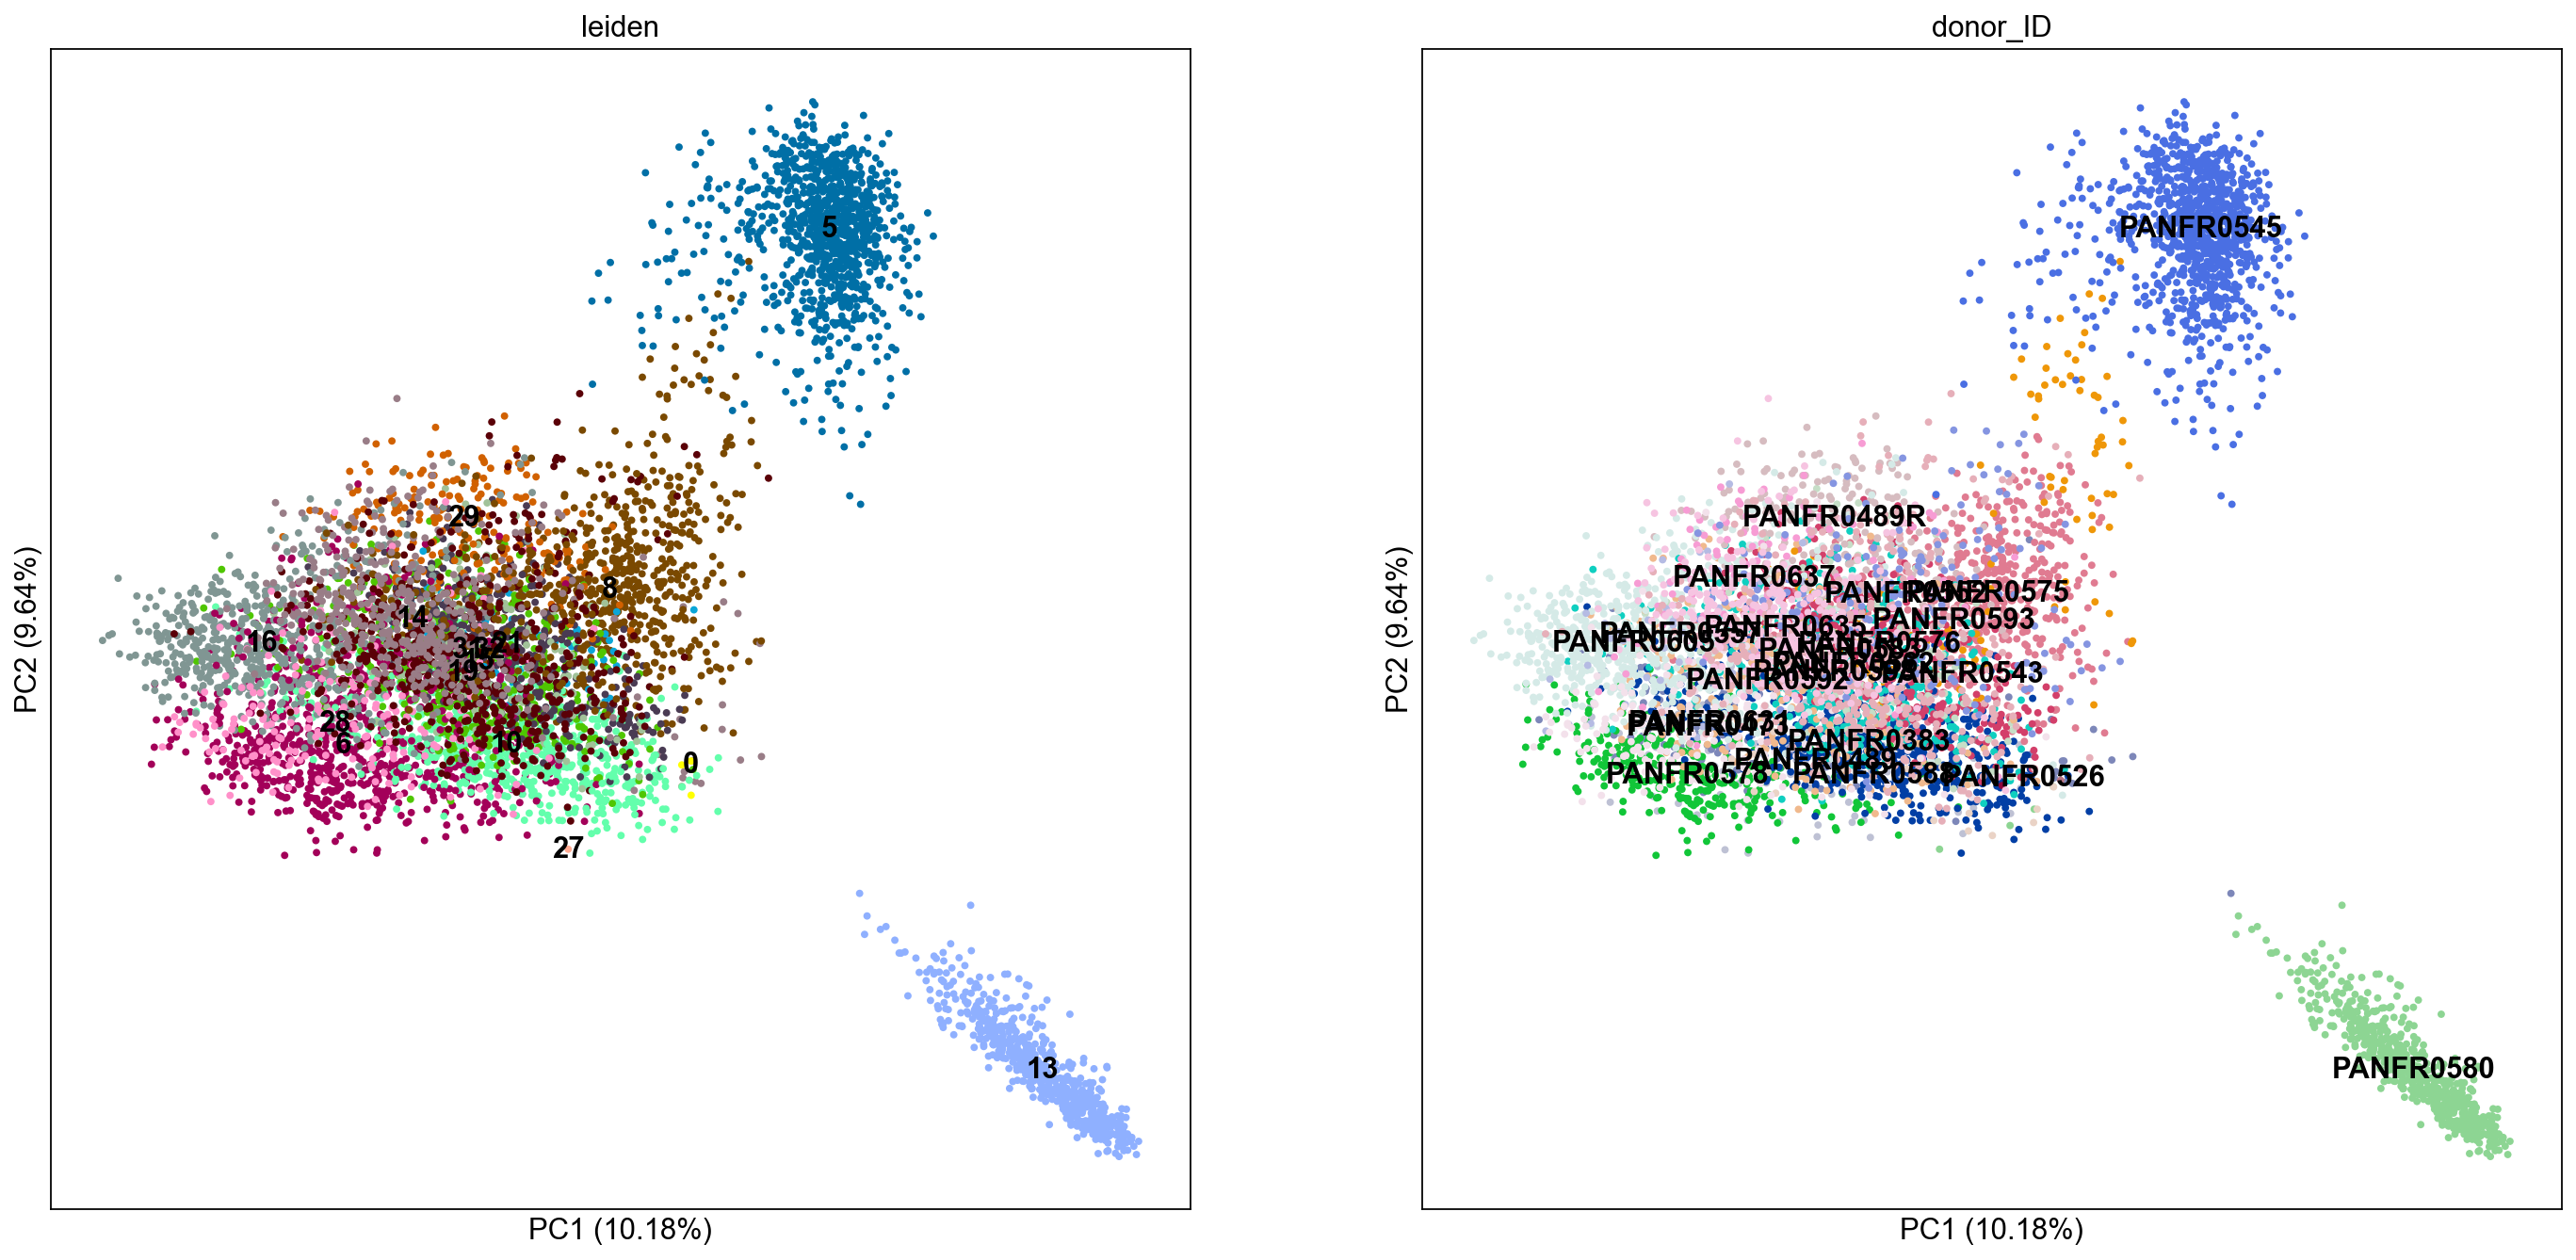

Removed ['PANFR0580', 'PANFR0526'] for < 25 cells


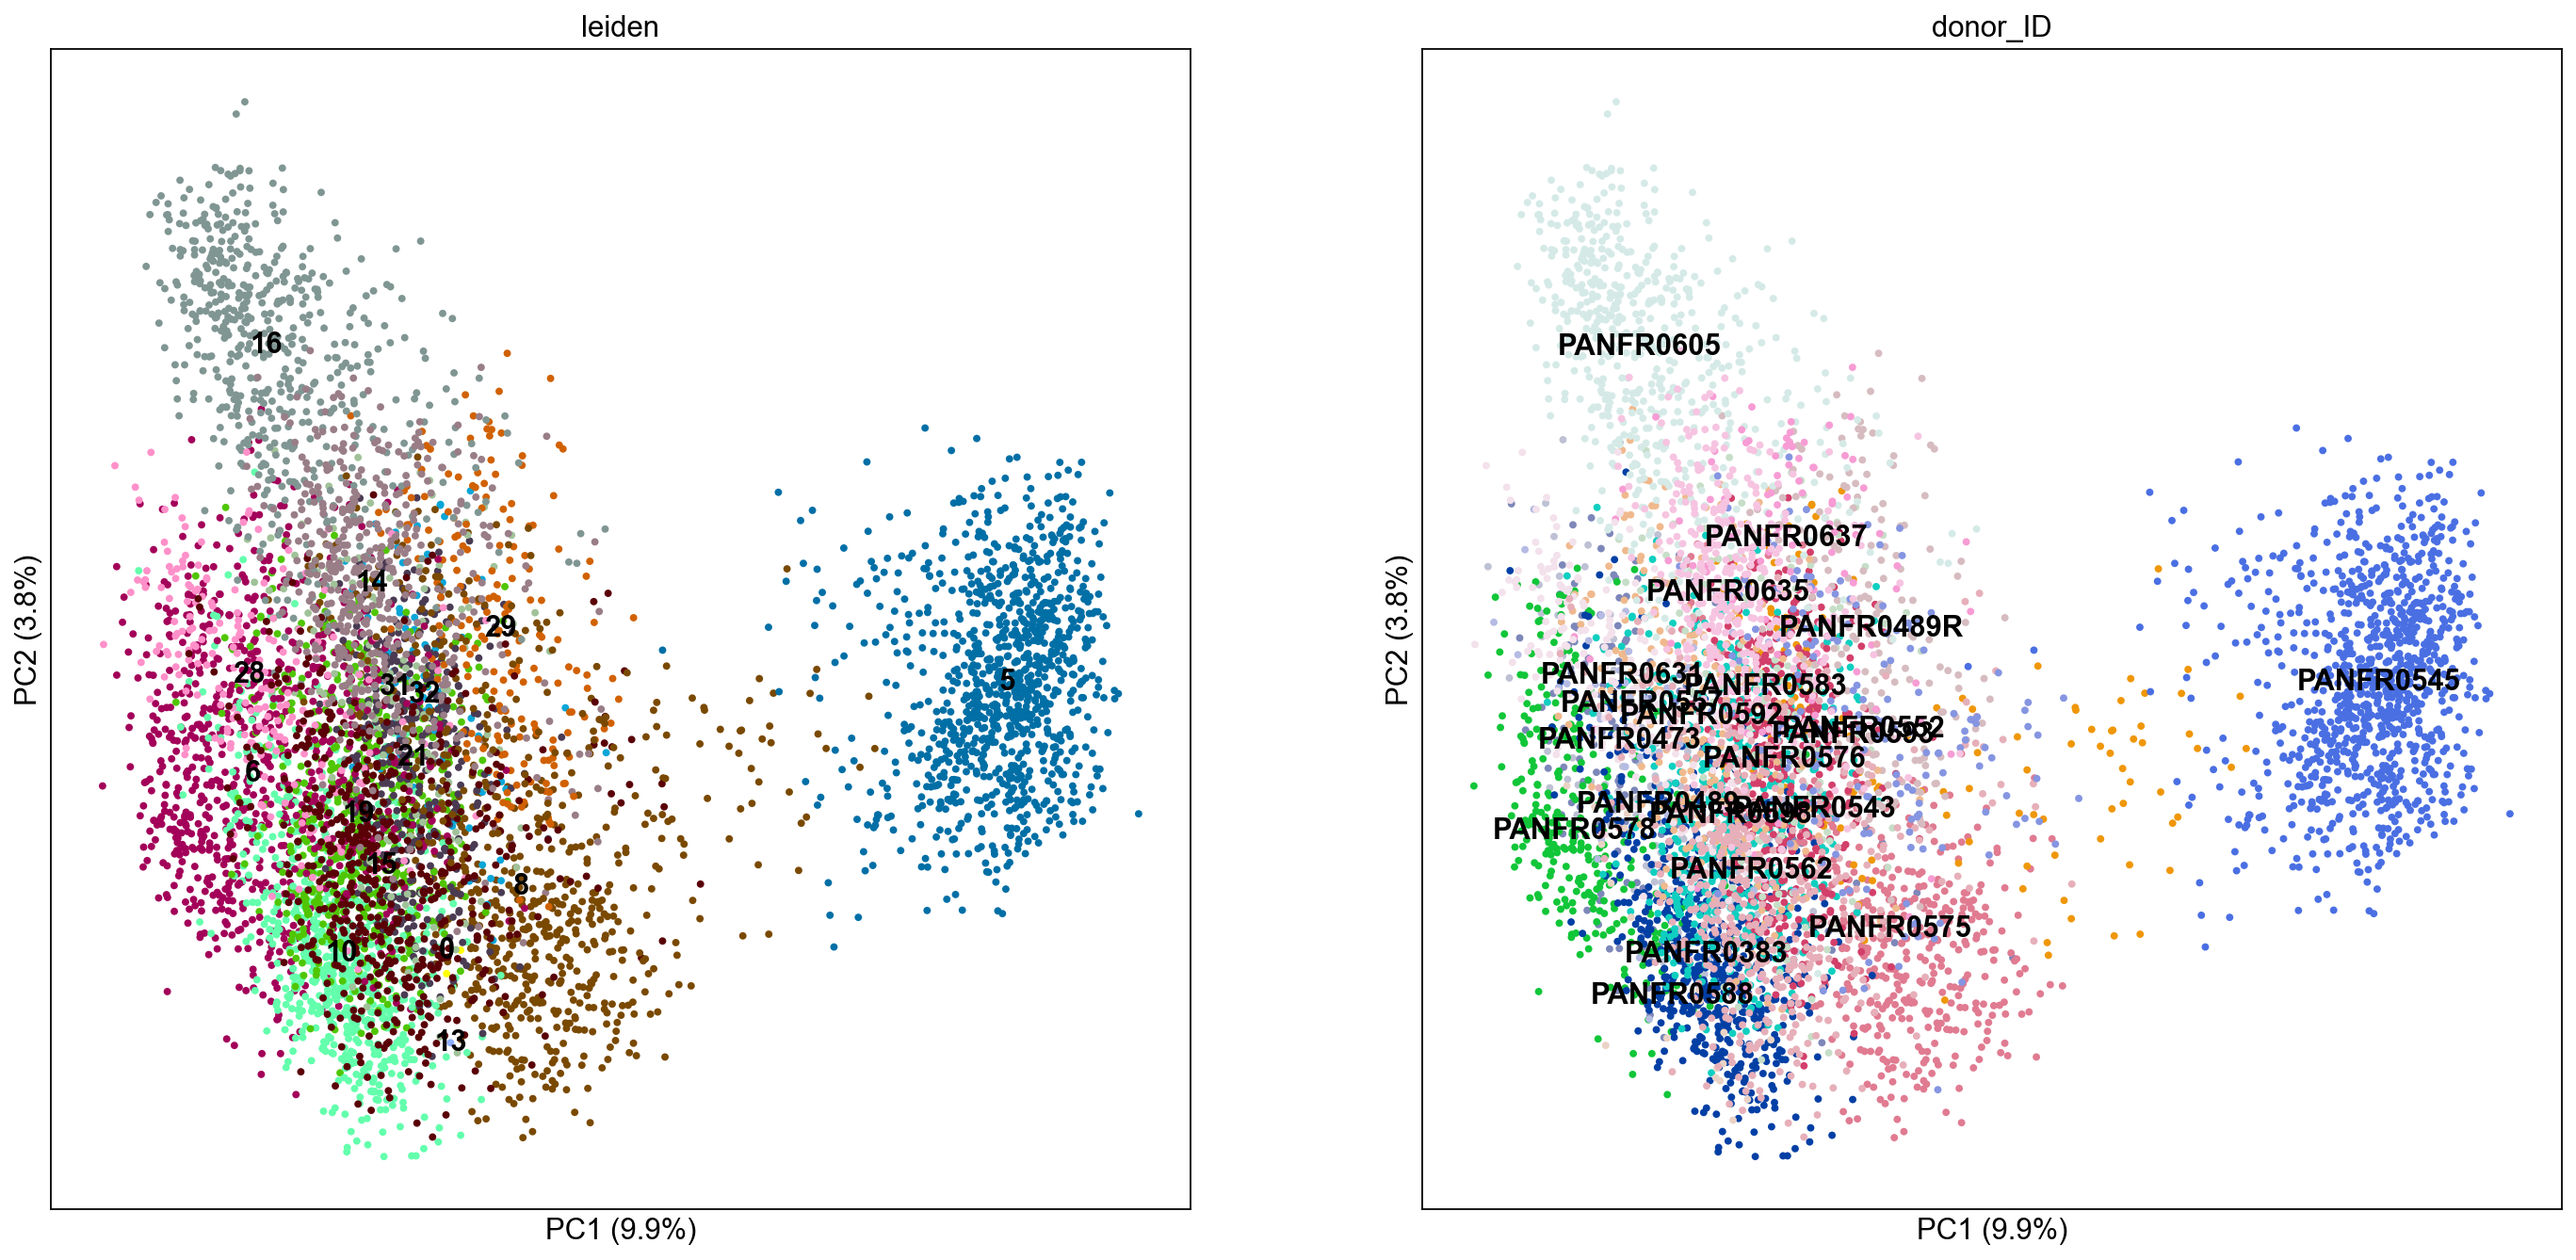

Final tumor PCA and tSNE


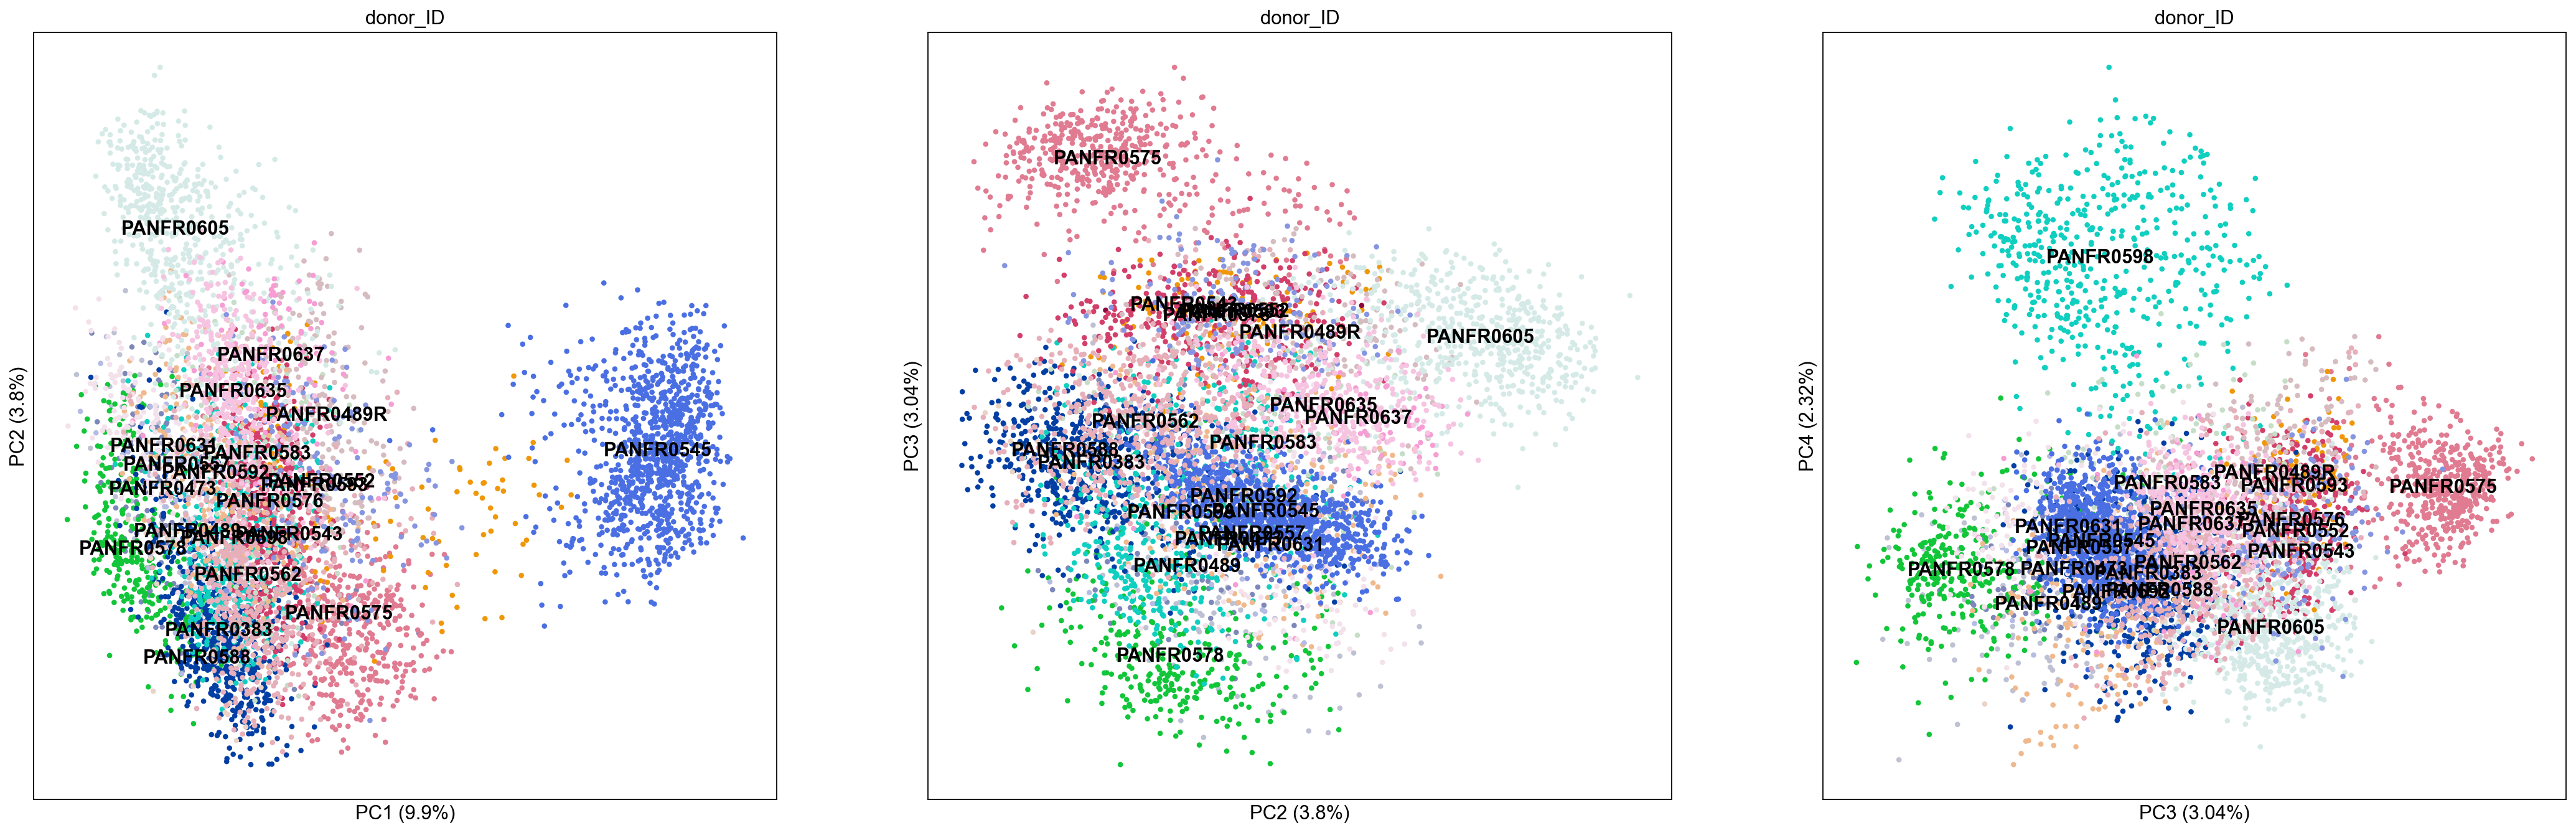

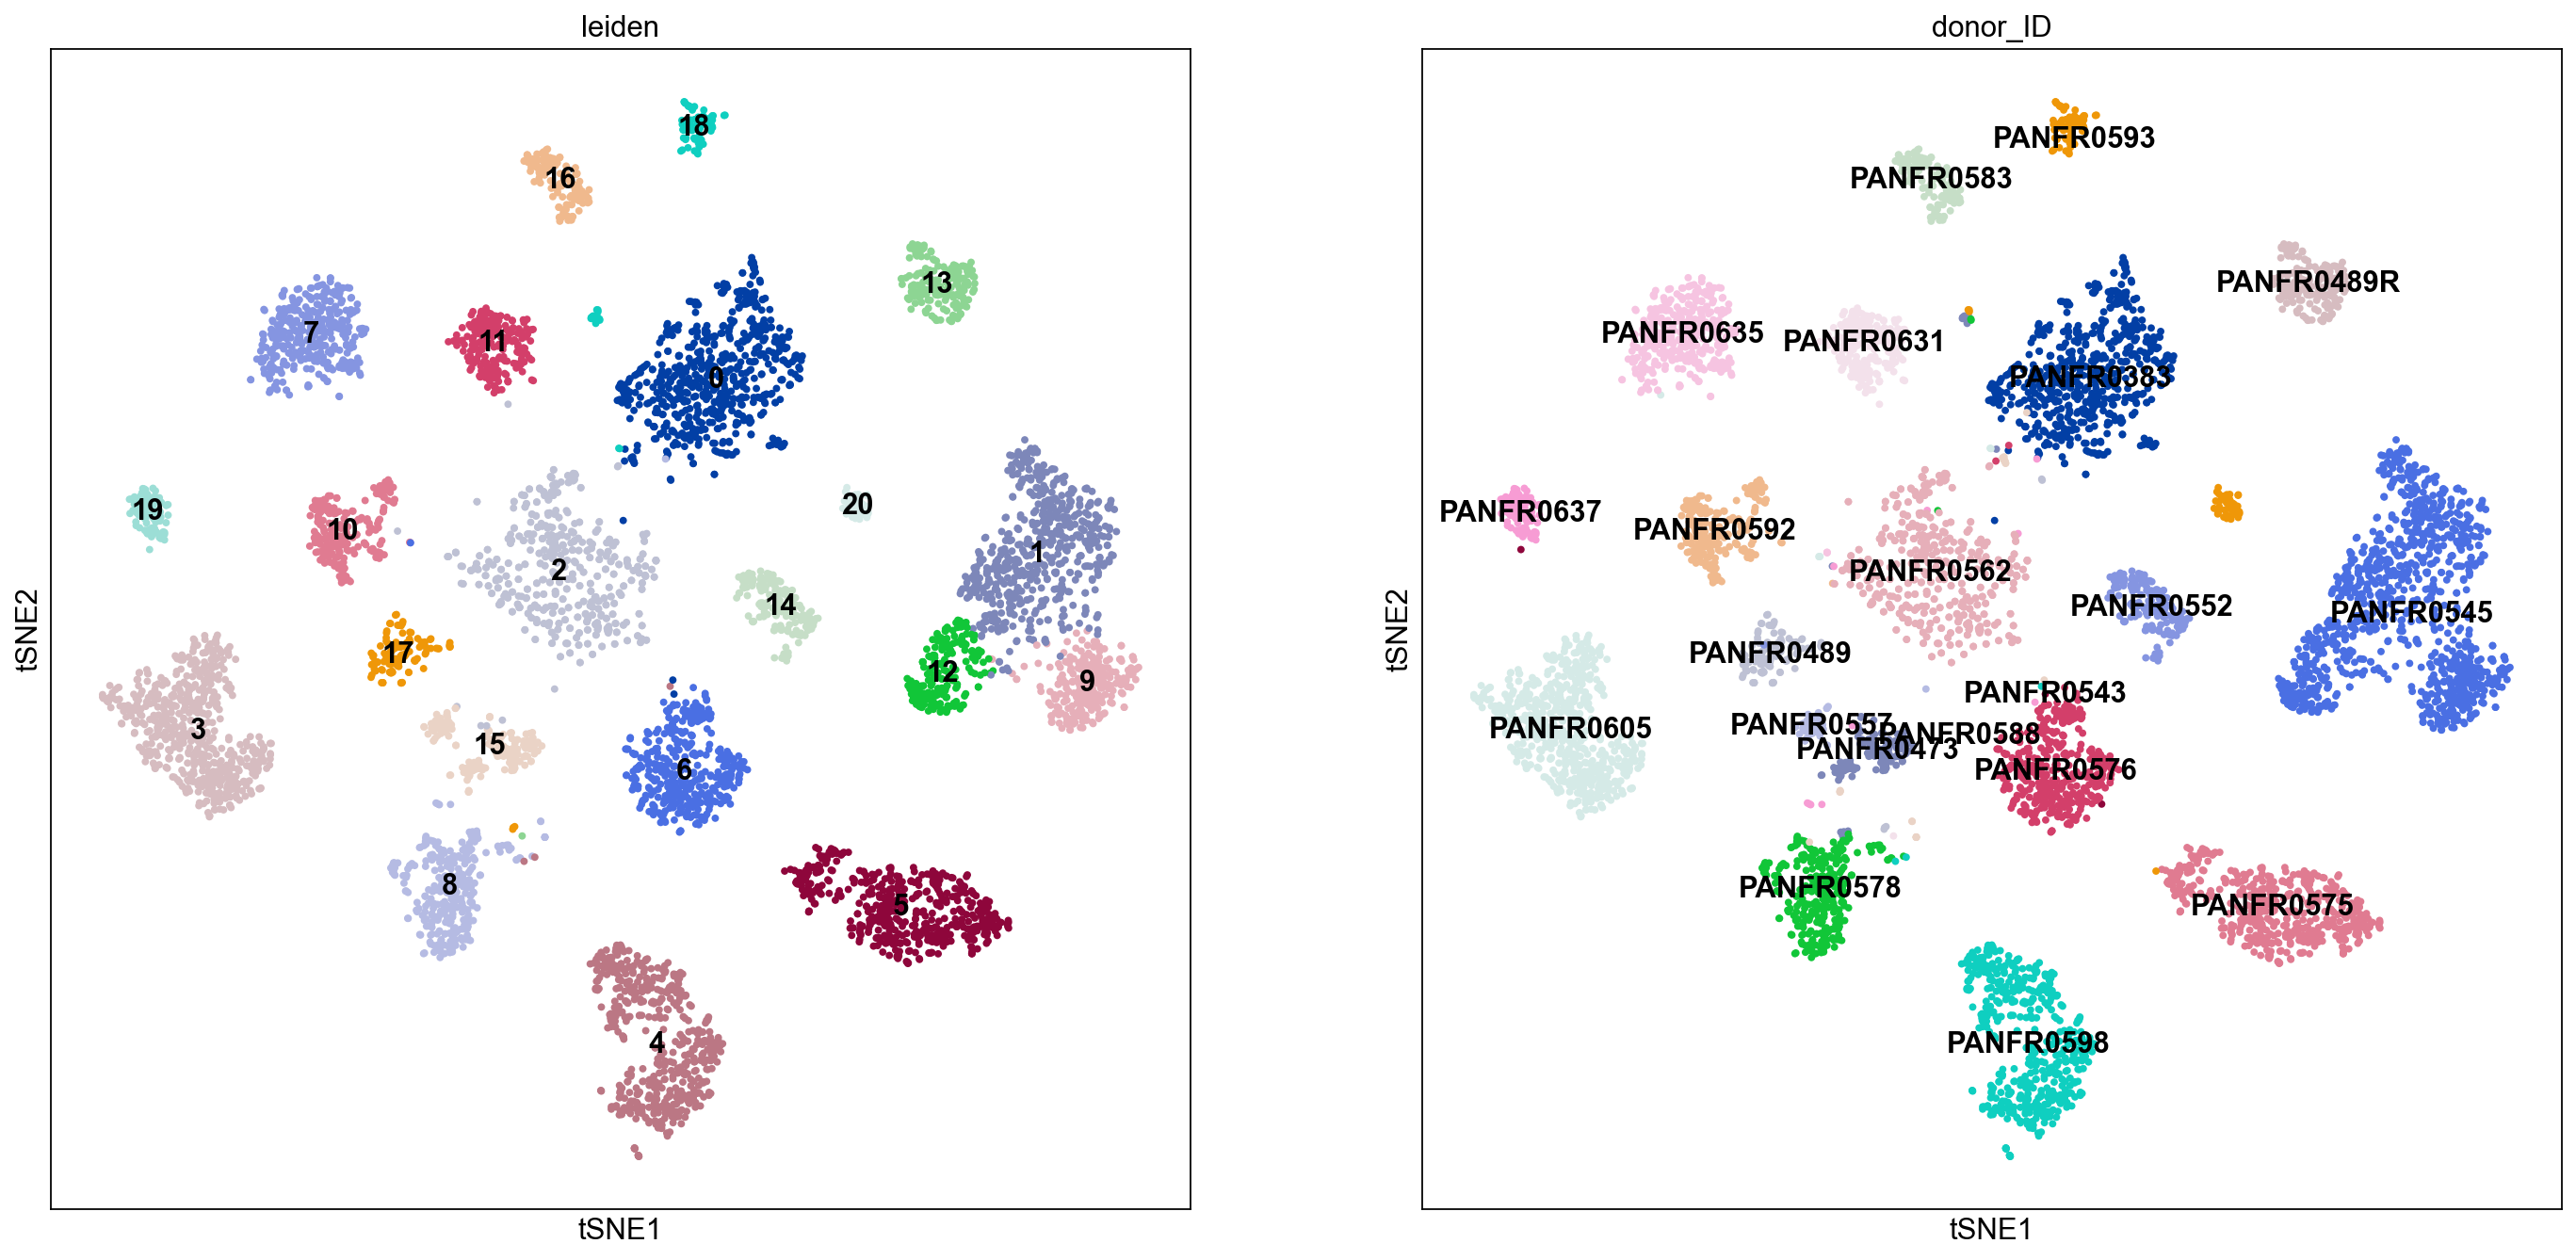

21
Counter({'PANFR0545': 1017, 'PANFR0383': 646, 'PANFR0605': 564, 'PANFR0562': 553, 'PANFR0598': 529, 'PANFR0575': 496, 'PANFR0576': 382, 'PANFR0635': 348, 'PANFR0578': 311, 'PANFR0592': 227, 'PANFR0631': 210, 'PANFR0489R': 190, 'PANFR0552': 176, 'PANFR0473': 147, 'PANFR0593': 140, 'PANFR0583': 136, 'PANFR0489': 124, 'PANFR0637': 105, 'PANFR0557': 44, 'PANFR0588': 22, 'PANFR0543': 3})
                0         1         2         3         4         5
CEACAM6 -0.140634  0.094106 -0.080433 -0.112699  0.170817  0.003501
LYZ     -0.093335 -0.028006 -0.166766  0.070686  0.054094 -0.098267
CEACAM5 -0.089933  0.112429 -0.044644 -0.079419  0.129625 -0.048609
S100P   -0.089874  0.000991 -0.031485 -0.006831 -0.047009  0.058781
CTSE    -0.089171 -0.006424 -0.147676 -0.012159  0.086252 -0.073183
LGALS4  -0.088316 -0.032746 -0.153998 -0.033392  0.110755 -0.019389
TSPAN8  -0.082164  0.026653 -0.112447 -0.060333  0.072226 -0.003234
LCN2    -0.081579  0.093027  0.001470 -0.064694 -0.120421  0.060929

In [3]:
scp1644_tumor = mship.tumor_study(scp1644_filter)

In [5]:
print(scp1644_tumor)

AnnData object with n_obs × n_vars = 6370 × 16604
    obs: 'biosample_id', 'donor_ID', 'Genes', 'UMI', 'dataset', 'sample.type', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'Coarse_Cell_Annotations', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'u400genes', 'u1000counts', 'o50mtpct', 'o8000genes', 'doublet_score', 'predicted_doublet', 'leiden', 'GGB_MITOCHONDRIAL'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'low_qual_u50cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_ID_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'scrublet', 'tsne', 'umap'
    obsm: 'X_pca',

In [7]:
clean_adata = scp1644_tumor
pc_output = pd.DataFrame(clean_adata.varm['PCs'][:, 0:6], index=clean_adata.var_names).sort_values(0)
with pd.option_context('display.min_rows', 50):
    print(pc_output)

for pc in range(6):
    ”’

                0         1         2         3         4         5
CEACAM6 -0.140634  0.094106 -0.080433 -0.112699  0.170817  0.003501
LYZ     -0.093335 -0.028006 -0.166766  0.070686  0.054094 -0.098267
CEACAM5 -0.089933  0.112429 -0.044644 -0.079419  0.129625 -0.048609
S100P   -0.089874  0.000991 -0.031485 -0.006831 -0.047009  0.058781
CTSE    -0.089171 -0.006424 -0.147676 -0.012159  0.086252 -0.073183
LGALS4  -0.088316 -0.032746 -0.153998 -0.033392  0.110755 -0.019389
TSPAN8  -0.082164  0.026653 -0.112447 -0.060333  0.072226 -0.003234
LCN2    -0.081579  0.093027  0.001470 -0.064694 -0.120421  0.060929
SPINK1  -0.081481 -0.106997 -0.152206 -0.115746  0.026938  0.181819
AGR2    -0.077905 -0.027997 -0.116447 -0.062322  0.106581  0.048031
CLDN4   -0.065866  0.067319 -0.005953  0.114282 -0.003587  0.072586
SLC40A1 -0.065615  0.054952 -0.090205 -0.005347  0.019643 -0.062438
GCNT3   -0.062939  0.035002 -0.033644  0.015443  0.046056  0.030667
SAT1    -0.060582  0.022056  0.010739  0.062220 

In [ ]:

sc.pl.pca(scp1644_clean_II, color='donor_ID', size=60, annotate_var_explained=True, dimensions=[(0, 1), (1, 2), (2, 3)], legend_loc="on data")
